# Melbourne Street Network Analysis

Collect street network data and analyse it ready for use in modelling

In [2]:
import requests  # for downloading data
import os

import pandas as pd
import geopandas as gpd
import contextily as cx

from zipfile import ZipFile

## Load data

~First some other data so that we know the spatial extent of the area that we are using.  Use the landmarks data from the [Melbourne Open Data Portal](https://data.melbourne.vic.gov.au/People/Landmarks-and-places-of-interest-including-schools/j5vt-ppat)~

_This was unnecessary because the road network data we download are already clipped to the area of interest_

Now get the road network data. Use the [pedestrian route data](https://data.melbourne.vic.gov.au/Transport/Pedestrian-Network/4id4-tydi) that are already available. These are shared as a `zip` file so download and extract that first if needed.

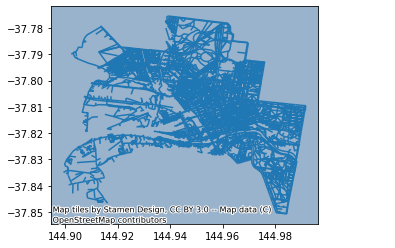

In [24]:
network_file = "Pedestrian_network.json"
property_file = "Property_centroid.json"

if not os.path.exists(network_file):
    zip_filename = "Pedestrian_Network.zip"
    print("Street network data doesn't exist, downloading ...",)
    url = "https://data.melbourne.vic.gov.au/download/4id4-tydi/application%2Fzip"
    response = requests.get(url)
    with open(zip_filename, 'wb') as f:
        f.write(response.content) 
    print("\t ... finished. Extracting zipfile ...",)
    with ZipFile(zip_filename, 'r') as zObject:
        zObject.extractall()
    # Should have two new files
    assert os.path.exists(network_file)
    assert os.path.exists(property_file)
    os.remove(zip_filename)
    
network = gpd.read_file(network_file, crs="EPSG:4326")
ax = network.plot()
cx.add_basemap(ax, zoom=12)